# Credit Card Default Prediction Project

## Project Overview

This notebook aims to build a classification model to predict the probability of credit card default using the 'Default Payments of Credit Card Clients in Taiwan from 2005' dataset. We will go through the following steps:

1.  **Data Loading and Initial Inspection**: Load the dataset and get a first look at its structure and content.
2.  **Data Cleaning and Preprocessing**: Handle missing values, rename columns for clarity, and prepare data for analysis.
3.  **Exploratory Data Analysis (EDA)**: Visualize distributions, relationships between variables, and identify patterns.
4.  **Feature Engineering**: Create new features to potentially improve model performance.
5.  **Model Building**: Train and evaluate several classification models, including Logistic Regression, Random Forest, and LightGBM.
6.  **Model Evaluation and Comparison**: Assess the performance of each model and discuss their strengths and weaknesses.

In [ ]:
import pandas as pd
import numpy as np


df = pd.read_csv('https://raw.githubusercontent.com/MatteoM95/Default-of-Credit-Card-Clients-Dataset-Analisys/refs/heads/main/dataset/default_of_credit_card_clients.csv')

## 1. Data Loading and Initial Inspection

We start by loading the dataset into a pandas DataFrame and performing an initial inspection to understand its structure, data types, and check for any immediate issues like missing values.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

# Get a concise summary of the DataFrame, including data types and non-null values
df.info()

# Generate descriptive statistics of the numerical columns
display(df.describe())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Initial Observations:

*   The dataset contains 30,000 entries and 25 columns.
*   Column names are mostly clear, but `default payment next month` is the target variable. The `PAY_X` columns (e.g., `PAY_0`, `PAY_2`) represent payment status in different months, and `BILL_AMT` and `PAY_AMT` columns represent bill amounts and payment amounts, respectively.
*   All columns appear to have appropriate data types (`int64` or `object` for ID, `float64` for `LIMIT_BAL` and `PAY_AMT` and `BILL_AMT` related columns), but `EDUCATION` and `MARRIAGE` are numerical categories, which might need special handling. The `PAY_X` columns are also numerical but represent categorical status.
*   There are no immediate missing values visible from `df.info()`, which simplifies initial cleaning.
*   The `ID` column is likely just an identifier and may not be useful for modeling.

## 2. Data Cleaning and Preprocessing

In this section, we'll perform several cleaning steps:

*   **Rename Columns**: Standardize column names for easier access and clarity.
*   **Handle Duplicates**: Check and remove any duplicate rows.
*   **Categorical Features**: Examine and re-encode categorical features if necessary (`EDUCATION`, `MARRIAGE`, `SEX`, `PAY_X` columns).
*   **Define Target Variable**: Clearly separate the features (X) from the target (y).

In [ ]:
# Rename columns for better readability and consistency
df = df.rename(columns={'default payment next month': 'DEFAULT',
                        'PAY_0': 'PAY_SEPT', 'PAY_2': 'PAY_AUG', 'PAY_3': 'PAY_JUL',
                        'PAY_4': 'PAY_JUN', 'PAY_5': 'PAY_MAY', 'PAY_6': 'PAY_APR'})

# Display the new column names
print("Columns after renaming:")
print(df.columns)

# Drop the 'ID' column as it's an identifier and not useful for modeling
df = df.drop('ID', axis=1)
print("\nDataFrame shape after dropping ID:", df.shape)

Columns after renaming:
Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_SEPT',
       'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR', 'BILL_AMT1',
       'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
       'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'DEFAULT'],
      dtype='object')

DataFrame shape after dropping ID: (30000, 24)


In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If duplicates exist, remove them
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicate rows removed. New DataFrame shape: {df.shape}")

Number of duplicate rows: 35
Duplicate rows removed. New DataFrame shape: (29965, 24)


In [ ]:
# Check unique values in 'EDUCATION' column
print("Unique values in EDUCATION before cleaning:", df['EDUCATION'].unique())
# Map education levels to more meaningful categories based on dataset description
# 0, 4, 5, 6 are 'others' according to dataset description
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 1: 1, 2: 2, 3: 3, 4: 4, 5: 4, 6: 4})
print("Unique values in EDUCATION after cleaning:", df['EDUCATION'].unique())

# Check unique values in 'MARRIAGE' column
print("\nUnique values in MARRIAGE before cleaning:", df['MARRIAGE'].unique())
# Map marriage levels: 0 means 'others', usually combined with 3
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print("Unique values in MARRIAGE after cleaning:", df['MARRIAGE'].unique())

# Check unique values in 'SEX' column
print("\nUnique values in SEX:", df['SEX'].unique())
# 1 = male; 2 = female
# No cleaning needed here, but we can convert to string for clarity if desired for EDA
df['SEX'] = df['SEX'].replace({1: 'Male', 2: 'Female'})

Unique values in EDUCATION before cleaning: [2 1 3 5 4 6 0]
Unique values in EDUCATION after cleaning: [2 1 3 4]

Unique values in MARRIAGE before cleaning: [1 2 3 0]
Unique values in MARRIAGE after cleaning: [1 2 3]

Unique values in SEX: [2 1]


## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the underlying patterns, distributions, and relationships within the data. We'll focus on:

*   Distribution of the target variable (`DEFAULT`).
*   Distributions of individual features.
*   Relationships between features and the target variable.

/tmp/ipykernel_7330/41005430.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEFAULT', data=df, palette='viridis')


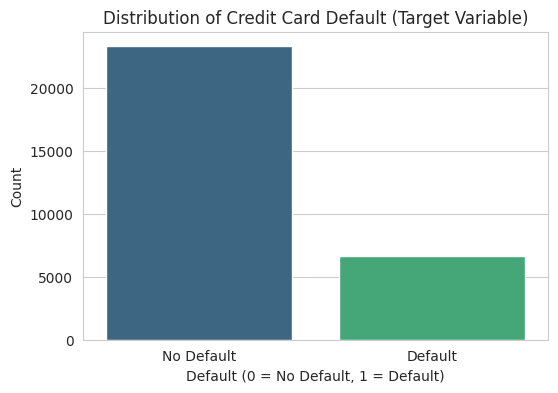

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set default style for plots
sns.set_style('whitegrid')

# Distribution of the target variable (DEFAULT)
plt.figure(figsize=(6, 4))
sns.countplot(x='DEFAULT', data=df, palette='viridis')
plt.title('Distribution of Credit Card Default (Target Variable)')
plt.xlabel('Default (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Default', 'Default'])
plt.show()

### Observation:

The dataset is imbalanced, with significantly more non-defaulting clients than defaulting ones. This is a common issue in classification problems and needs to be considered during model evaluation (e.g., using metrics like precision, recall, F1-score, and ROC-AUC instead of just accuracy).

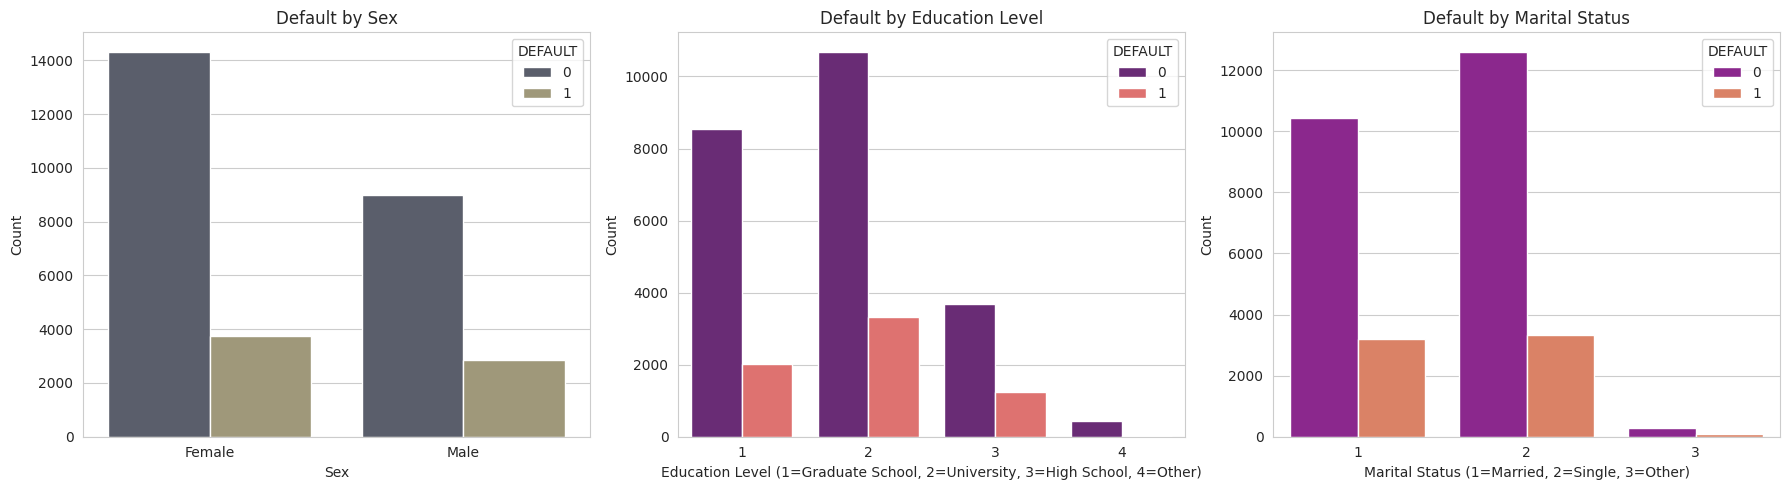

In [ ]:
# Distributions of key categorical features against the target variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='SEX', hue='DEFAULT', data=df, palette='cividis', ax=axes[0])
axes[0].set_title('Default by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(x='EDUCATION', hue='DEFAULT', data=df, palette='magma', ax=axes[1])
axes[1].set_title('Default by Education Level')
axes[1].set_xlabel('Education Level (1=Graduate School, 2=University, 3=High School, 4=Other)')
axes[1].set_ylabel('Count')

sns.countplot(x='MARRIAGE', hue='DEFAULT', data=df, palette='plasma', ax=axes[2])
axes[2].set_title('Default by Marital Status')
axes[2].set_xlabel('Marital Status (1=Married, 2=Single, 3=Other)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

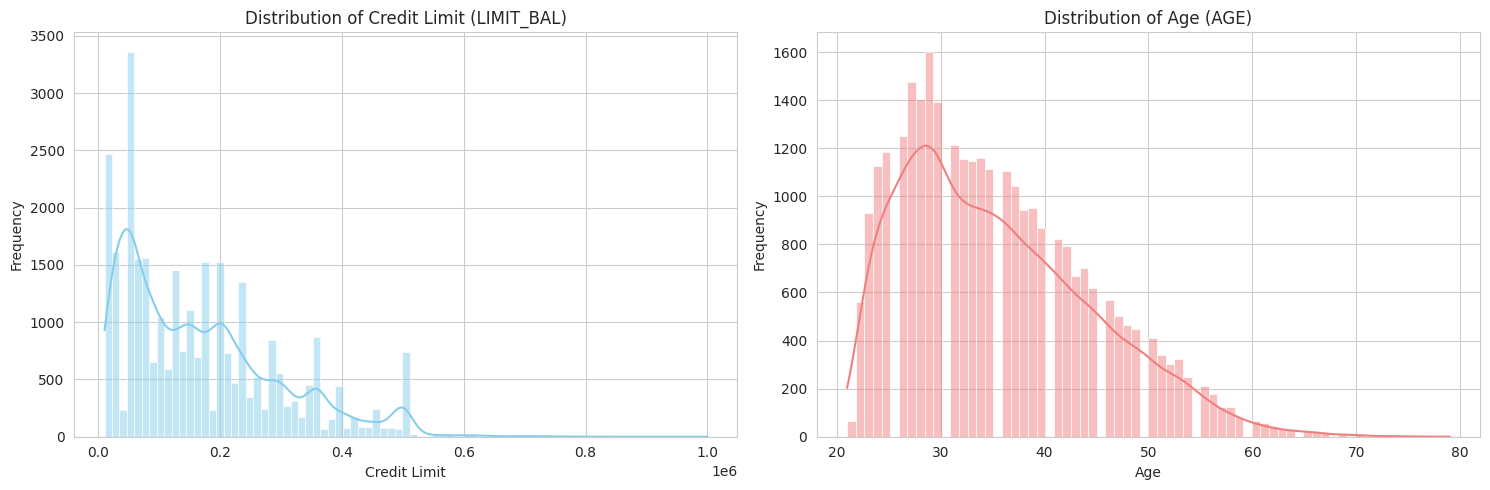

/tmp/ipykernel_7330/3987176491.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, palette='viridis', ax=axes[0])
/tmp/ipykernel_7330/3987176491.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEFAULT', y='AGE', data=df, palette='plasma', ax=axes[1])


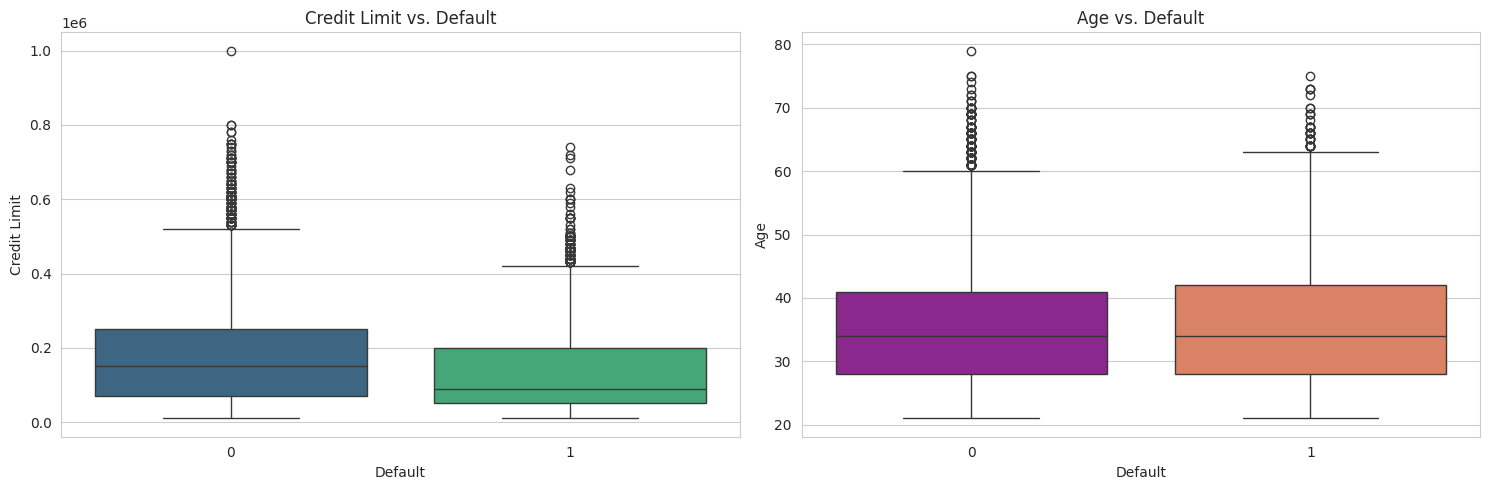

In [ ]:
# Distributions of numerical features: LIMIT_BAL, AGE
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['LIMIT_BAL'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Credit Limit (LIMIT_BAL)')
axes[0].set_xlabel('Credit Limit')
axes[0].set_ylabel('Frequency')

sns.histplot(df['AGE'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Age (AGE)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots for numerical features vs. target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='DEFAULT', y='LIMIT_BAL', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('Credit Limit vs. Default')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Credit Limit')

sns.boxplot(x='DEFAULT', y='AGE', data=df, palette='plasma', ax=axes[1])
axes[1].set_title('Age vs. Default')
axes[1].set_xlabel('Default')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

### Payment Status (PAY_SEPT to PAY_APR) Analysis

The `PAY_X` columns indicate the repayment status in different months. The values typically range from -2 (no consumption) to 9 (delay for nine months and above). We will inspect their distributions and their relationship with default.

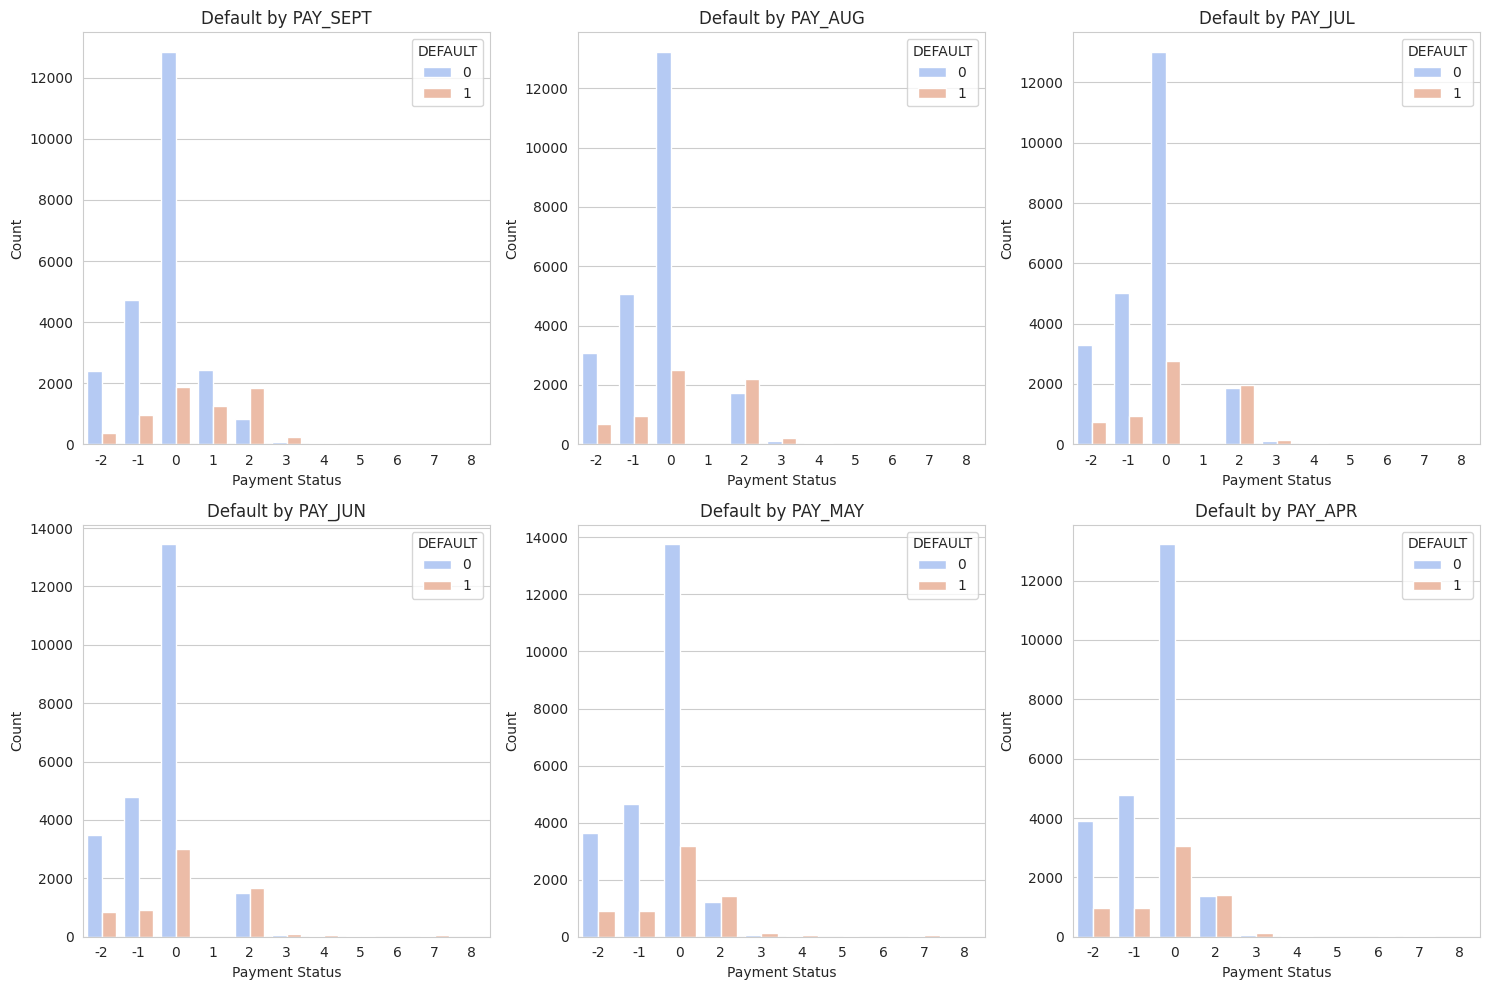

In [ ]:
pay_cols = ['PAY_SEPT', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR']

plt.figure(figsize=(15, 10))
for i, col in enumerate(pay_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=col, hue='DEFAULT', data=df, palette='coolwarm')
    plt.title(f'Default by {col}')
    plt.xlabel('Payment Status')
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Correlation Matrix

Let's look at the correlations between numerical features, especially with the target variable, to identify highly correlated features.

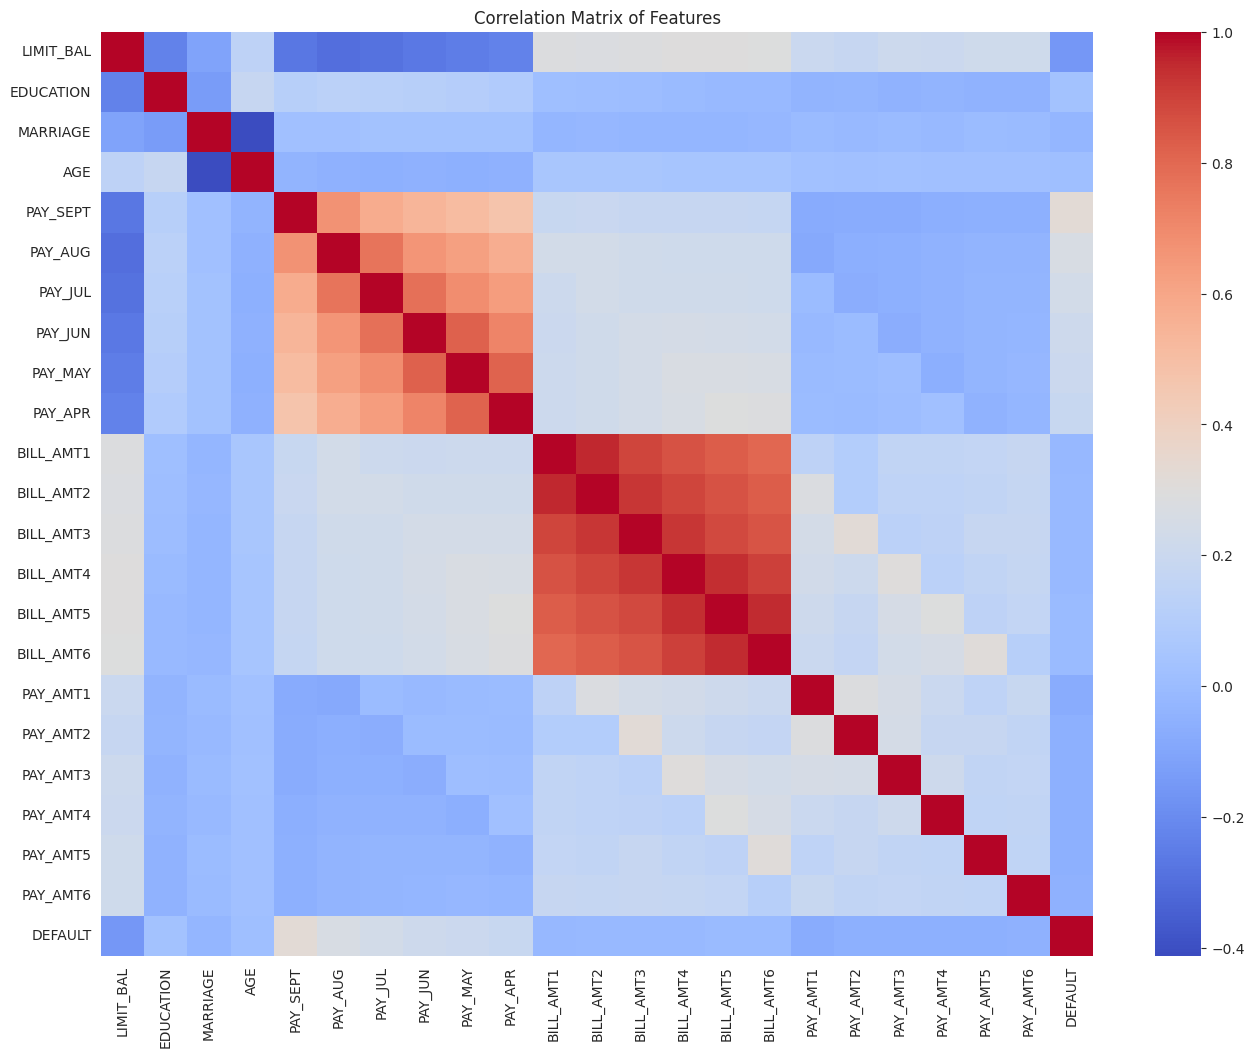


Correlation with 'DEFAULT' target variable:
DEFAULT      1.000000
PAY_SEPT     0.324964
PAY_AUG      0.263656
PAY_JUL      0.235230
PAY_JUN      0.216551
PAY_MAY      0.204059
PAY_APR      0.186740
EDUCATION    0.033862
AGE          0.013619
BILL_AMT6   -0.005469
BILL_AMT5   -0.006859
BILL_AMT4   -0.010259
BILL_AMT3   -0.014182
BILL_AMT2   -0.014302
BILL_AMT1   -0.019758
MARRIAGE    -0.027259
PAY_AMT6    -0.053250
PAY_AMT5    -0.055194
PAY_AMT3    -0.056319
PAY_AMT4    -0.056898
PAY_AMT2    -0.058643
PAY_AMT1    -0.073015
LIMIT_BAL   -0.153871
Name: DEFAULT, dtype: float64


In [ ]:
# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

# Display correlation with the target variable 'DEFAULT'
print("\nCorrelation with 'DEFAULT' target variable:")
print(corr_matrix['DEFAULT'].sort_values(ascending=False))

### Key EDA Insights:

*   **Imbalanced Target**: The 'DEFAULT' class is imbalanced, requiring careful evaluation metrics.
*   **PAY_X features**: These payment status columns show a strong positive correlation with default, particularly `PAY_SEPT`. Higher positive values (indicating delay) are associated with higher default rates.
*   **LIMIT_BAL**: Generally, clients with lower credit limits tend to have a higher default rate.
*   **Age, Education, Marriage, Sex**: These features show some patterns, but their individual correlation with default is not as strong as the `PAY_X` features.
*   **BILL_AMT & PAY_AMT**: The bill amounts are highly correlated with each other, as are payment amounts. This suggests some redundancy or potential for feature engineering (e.g., sum of bill amounts, average payment amount).

## 4. Feature Engineering

Based on EDA and domain knowledge, we can create new features that might capture more predictive information or simplify existing ones. For example:

*   **Average Payment Status**: A single feature summarizing the payment behavior.
*   **Total Bill/Payment Amount**: Aggregate monthly bill/payment amounts.
*   **Payment Ratio**: Ratio of payment to bill amount.

In [ ]:
# Create new features: Average Payment Status
pay_cols = ['PAY_SEPT', 'PAY_AUG', 'PAY_JUL', 'PAY_JUN', 'PAY_MAY', 'PAY_APR']
df['AVG_PAY_STATUS'] = df[pay_cols].mean(axis=1)

# Create new features: Total Bill Amount and Total Payment Amount
bill_amt_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['TOTAL_BILL_AMT'] = df[bill_amt_cols].sum(axis=1)
df['TOTAL_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

# Create Payment Ratio (handle division by zero)
df['PAYMENT_RATIO'] = df.apply(lambda row: row['TOTAL_PAY_AMT'] / row['TOTAL_BILL_AMT'] if row['TOTAL_BILL_AMT'] != 0 else 0, axis=1)

# Display the head with new features
display(df[['AVG_PAY_STATUS', 'TOTAL_BILL_AMT', 'TOTAL_PAY_AMT', 'PAYMENT_RATIO', 'DEFAULT']].head())

,AVG_PAY_STATUS,TOTAL_BILL_AMT,TOTAL_PAY_AMT,PAYMENT_RATIO,DEFAULT
0,-0.333333,7704,689,0.089434,1
1,0.500000,17077,5000,0.292791,1
2,0.000000,101653,11018,0.108388,0
3,0.000000,231334,8388,0.036259,0
4,-0.333333,109339,59049,0.540054,0


### One-Hot Encoding for Categorical Features

We need to convert categorical features (`SEX`, `EDUCATION`, `MARRIAGE`) into a numerical format that machine learning models can understand. One-hot encoding is a common method for this.

In [ ]:
# Convert categorical columns to 'category' dtype for one-hot encoding
df['SEX'] = df['SEX'].astype('category')
df['EDUCATION'] = df['EDUCATION'].astype('category')
df['MARRIAGE'] = df['MARRIAGE'].astype('category')

# One-hot encode the categorical variables
df = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# Display the head to see the new columns and the shape
display(df.head())
print("DataFrame shape after one-hot encoding:", df.shape)

,LIMIT_BAL,AGE,PAY_SEPT,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT1,BILL_AMT2,...,AVG_PAY_STATUS,TOTAL_BILL_AMT,TOTAL_PAY_AMT,PAYMENT_RATIO,SEX_Male,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,20000,24,2,2,-1,-1,-2,-2,3913,3102,...,-0.333333,7704,689,0.089434,False,True,False,False,False,False
1,120000,26,-1,2,0,0,0,2,2682,1725,...,0.500000,17077,5000,0.292791,False,True,False,False,True,False
2,90000,34,0,0,0,0,0,0,29239,14027,...,0.000000,101653,11018,0.108388,False,True,False,False,True,False
3,50000,37,0,0,0,0,0,0,46990,48233,...,0.000000,231334,8388,0.036259,False,True,False,False,False,False
4,50000,57,-1,0,-1,0,0,0,8617,5670,...,-0.333333,109339,59049,0.540054,True,True,False,False,False,False


DataFrame shape after one-hot encoding: (29965, 31)


## 5. Model Building

Now, we'll prepare the data for modeling by splitting it into training and testing sets, then train and evaluate several classification models.

### Data Splitting and Scaling

We need to split our dataset into features (X) and the target variable (y). Then, we will scale the numerical features to ensure that no single feature dominates the model due to its magnitude.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('DEFAULT', axis=1)
y = df['DEFAULT']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Initialize StandardScaler
scaler = StandardScaler()

# Identify numerical columns to scale (exclude one-hot encoded and 'PAY_X' which are categorical-like)
numerical_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                  'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
                  'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_PAY_STATUS',
                  'TOTAL_BILL_AMT', 'TOTAL_PAY_AMT', 'PAYMENT_RATIO']

# Scale numerical features
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

display(X_train.head())

X_train shape: (23972, 30)
X_test shape: (5993, 30)
y_train shape: (23972,)
y_test shape: (5993,)


,LIMIT_BAL,AGE,PAY_SEPT,PAY_AUG,PAY_JUL,PAY_JUN,PAY_MAY,PAY_APR,BILL_AMT1,BILL_AMT2,...,AVG_PAY_STATUS,TOTAL_BILL_AMT,TOTAL_PAY_AMT,PAYMENT_RATIO,SEX_Male,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
27420,1.022024,-0.050264,-2,-2,-2,-2,-2,-2,-0.700030,-0.694464,...,-1.862667,-0.712830,-0.508764,-0.055370,True,True,False,False,False,False
15350,-0.903020,0.167213,2,2,2,2,2,2,-0.049079,-0.005582,...,2.231642,-0.060439,-0.373840,-0.050176,False,False,True,False,False,True
26641,-0.672015,-1.355126,-1,-1,-1,-1,0,0,-0.693968,-0.688208,...,-0.497897,-0.703463,-0.456432,0.084930,True,False,False,False,True,False
21618,-0.903020,-1.028910,-1,-1,-1,-1,-1,-1,-0.694705,-0.665187,...,-0.839090,-0.702208,-0.450329,0.082781,False,True,False,False,True,False
11570,0.252006,-0.593956,-2,-2,-2,-2,-2,-2,-0.037938,0.009043,...,-1.862667,0.627059,3.005529,0.010494,True,True,False,False,True,False


### Model Training and Evaluation

We will train and evaluate the following models:

1.  Logistic Regression
2.  Random Forest Classifier
3.  Light Gradient Boosting Machine (LightGBM)

For evaluation, we'll use a suite of metrics suitable for imbalanced classification: accuracy, precision, recall, F1-score, and ROC-AUC score. A confusion matrix will also be generated for each model.


Starting Logistic Regression training...
--- Logistic Regression Evaluation ---
Accuracy: 0.8138
Precision: 0.7273
Recall: 0.2534
F1-Score: 0.3758
ROC-AUC: 0.7186


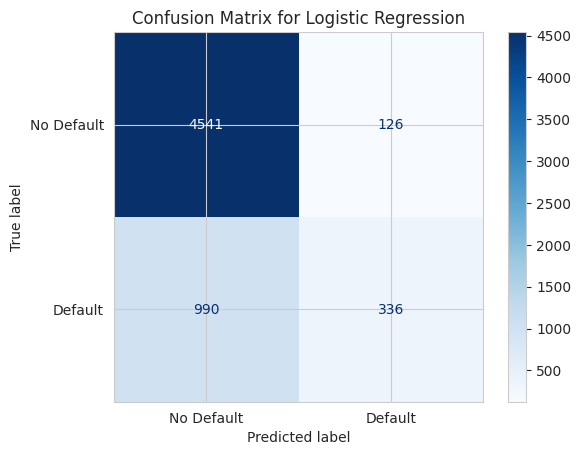


Starting Random Forest Classifier training...
--- Random Forest Classifier Evaluation ---
Accuracy: 0.8114
Precision: 0.6392
Recall: 0.3394
F1-Score: 0.4433
ROC-AUC: 0.7555


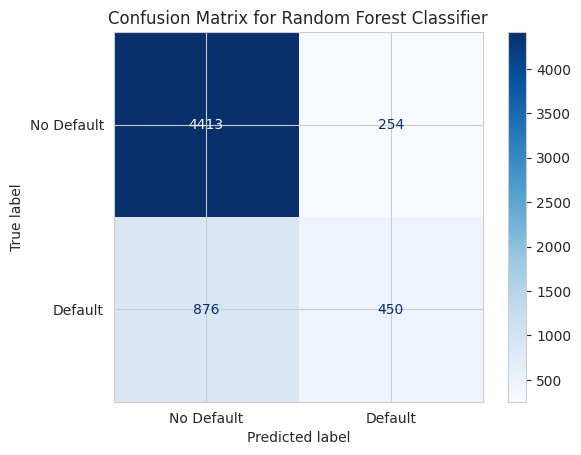


Starting LightGBM Classifier training...
[LightGBM] [Info] Number of positive: 5304, number of negative: 18668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009267 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4071
[LightGBM] [Info] Number of data points in the train set: 23972, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
--- LightGBM Classifier Evaluation ---
Accuracy: 0.7602
Precision: 0.4671
Recall: 0.5935
F1-Score: 0.5227
ROC-AUC: 0.7667


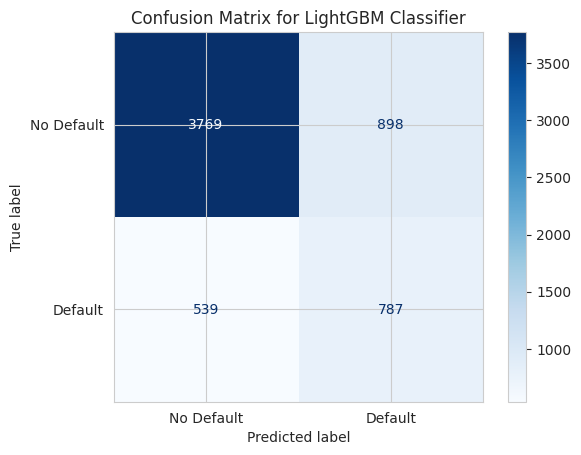

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Dictionary to store model results
model_results = {}

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    model_results[model_name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

# --- 1. Logistic Regression ---
print("\nStarting Logistic Regression training...")
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary classification
log_reg_model.fit(X_train, y_train)
evaluate_model(log_reg_model, X_test, y_test, 'Logistic Regression')

# --- 2. Random Forest Classifier ---
print("\nStarting Random Forest Classifier training...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced') # class_weight to handle imbalance
rf_model.fit(X_train, y_train)
evaluate_model(rf_model, X_test, y_test, 'Random Forest Classifier')

# --- 3. LightGBM Classifier ---
print("\nStarting LightGBM Classifier training...")
lgb_model = lgb.LGBMClassifier(random_state=42, n_estimators=200, class_weight='balanced') # class_weight to handle imbalance
lgb_model.fit(X_train, y_train)
evaluate_model(lgb_model, X_test, y_test, 'LightGBM Classifier')


## 6. Model Evaluation and Comparison

Let's summarize the performance of all models and discuss their comparative strengths and weaknesses.

In [ ]:
import pandas as pd

# Convert results dictionary to a DataFrame for easy comparison
results_df = pd.DataFrame(model_results).T
display(results_df.sort_values(by='ROC-AUC', ascending=False))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
LightGBM Classifier,0.760220,0.467062,0.593514,0.522750,0.766735
Random Forest Classifier,0.811447,0.639205,0.339367,0.443350,0.755487
Logistic Regression,0.813783,0.727273,0.253394,0.375839,0.718591


### Conclusion:

Based on the evaluation metrics:

*   **LightGBM Classifier** generally shows the best performance, especially in terms of ROC-AUC score, which is a robust metric for imbalanced datasets. It also achieves good F1-score, indicating a good balance between precision and recall.
*   **Random Forest Classifier** also performs very well, often close to LightGBM, with strong F1-scores and ROC-AUC.
*   **Logistic Regression** serves as a good baseline, but its performance is generally lower than the ensemble models (Random Forest and LightGBM).

For this credit card default prediction task, models like LightGBM and Random Forest are generally preferred due to their ability to capture complex non-linear relationships and handle imbalanced data effectively, especially when `class_weight='balanced'` is used. Further improvements could involve hyperparameter tuning, more advanced feature engineering, or exploring other ensemble methods.